In [1]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
import tarfile

tar_path = '/content/all_files_compressed.tar.gz'
extract_path = '/content/event_dataset'

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print("Extracted ✅")

/tmp/ipykernel_2433/294791811.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extracted ✅


In [3]:
def parse_xml_file(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        sentence_elem = root.find('sentence')
        events = [e.text for e in sentence_elem.findall('event')]
        plain_text = ''.join(sentence_elem.itertext())
        return {
            'plain_text': plain_text.strip(),
            'events': events,
            'num_events': len(events),
            'has_event': len(events) > 0
        }
    except ET.ParseError as e:
        # Try reading raw file and cleaning it
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()

            # Fix common problem characters in news text
            content = content.replace('&', '&amp;')

            root = ET.fromstring(content)
            sentence_elem = root.find('sentence')
            events = [e.text for e in sentence_elem.findall('event')]
            plain_text = ''.join(sentence_elem.itertext())
            return {
                'plain_text': plain_text.strip(),
                'events': events,
                'num_events': len(events),
                'has_event': len(events) > 0
            }
        except Exception as e2:
            print(f"Skipped (unfixable): {filepath} → {e2}")
            return None

train_dir = '/content/event_dataset/training'
test_dir  = '/content/event_dataset/testing'

train_records, test_records = [], []
skipped = 0

for filename in os.listdir(train_dir):
    if filename.endswith('.xml'):
        record = parse_xml_file(os.path.join(train_dir, filename))
        if record:                          # only add if parsing succeeded
            record['split'] = 'train'
            train_records.append(record)
        else:
            skipped += 1

for filename in os.listdir(test_dir):
    if filename.endswith('.xml'):
        record = parse_xml_file(os.path.join(test_dir, filename))
        if record:
            record['split'] = 'test'
            test_records.append(record)
        else:
            skipped += 1

train_df = pd.DataFrame(train_records)
test_df  = pd.DataFrame(test_records)
df       = pd.concat([train_df, test_df], ignore_index=True)

df.to_csv('/content/event_data.csv', index=False)

print(f"Train rows  : {len(train_df)}")
print(f"Test rows   : {len(test_df)}")
print(f"Total rows  : {len(df)}")
print(f"Skipped     : {skipped} files (bad XML)")
print(f"\nSaved as event_data.csv ✅")
print(df.head(3))

Train rows  : 2000
Test rows   : 200
Total rows  : 2200
Skipped     : 0 files (bad XML)

Saved as event_data.csv ✅
                                          plain_text  \
0  This summer, when Thailand was still reeling a...   
1  The Kia Motors Corporation, one of South Korea...   
2  The Soviet Union has announced a shift in its ...   

                                      events  num_events  has_event  split  
0                                         []           0      False  train  
1      [placed, announced, assistance, debt]           4       True  train  
2  [announced, shift, demands, crisis, said]           5       True  train  


### Specify Google Drive Path for Extracted Dataset

Provide the path in your Google Drive where the `event_dataset` should be extracted. This will be the base directory for `training` and `testing` subfolders.

In [4]:
#@title Enter the Google Drive path to extract the dataset
# Example: /content/drive/My Drive/event_dataset
EXTRACT_ROOT_DIR = '/content/drive/My Drive/event_dataset' #@param {type:"string"}

print(f"Extracted dataset will be saved to: {EXTRACT_ROOT_DIR}")

Extracted dataset will be saved to: /content/drive/My Drive/event_dataset


In [5]:
import tarfile
import os

tar_path = '/content/all_files_compressed.tar.gz' # Assuming this is still in Colab's local /content
extract_path = EXTRACT_ROOT_DIR # Use the user-defined Google Drive path

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(extract_path)

print(f"Extracted ✅ to {extract_path}")

/tmp/ipykernel_2433/3789544846.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extracted ✅ to /content/drive/My Drive/event_dataset


In [6]:
def parse_xml_file(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        sentence_elem = root.find('sentence')
        events = [e.text for e in sentence_elem.findall('event')]
        plain_text = ''.join(sentence_elem.itertext())
        return {
            'plain_text': plain_text.strip(),
            'events': events,
            'num_events': len(events),
            'has_event': len(events) > 0
        }
    except ET.ParseError as e:
        # Try reading raw file and cleaning it
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()

            # Fix common problem characters in news text
            content = content.replace('&', '&amp;')

            root = ET.fromstring(content)
            sentence_elem = root.find('sentence')
            events = [e.text for e in sentence_elem.findall('event')]
            plain_text = ''.join(sentence_elem.itertext())
            return {
                'plain_text': plain_text.strip(),
                'events': events,
                'num_events': len(events),
                'has_event': len(events) > 0
            }
        except Exception as e2:
            print(f"Skipped (unfixable): {filepath} → {e2}")
            return None

# Use the user-defined Google Drive path for the extracted dataset
train_dir = os.path.join(EXTRACT_ROOT_DIR, 'training')
test_dir  = os.path.join(EXTRACT_ROOT_DIR, 'testing')

train_records, test_records = [], []
skipped = 0

for filename in os.listdir(train_dir):
    if filename.endswith('.xml'):
        record = parse_xml_file(os.path.join(train_dir, filename))
        if record:                          # only add if parsing succeeded
            record['split'] = 'train'
            train_records.append(record)
        else:
            skipped += 1

for filename in os.listdir(test_dir):
    if filename.endswith('.xml'):
        record = parse_xml_file(os.path.join(test_dir, filename))
        if record:
            record['split'] = 'test'
            test_records.append(record)
        else:
            skipped += 1

train_df = pd.DataFrame(train_records)
test_df  = pd.DataFrame(test_records)
df       = pd.concat([train_df, test_df], ignore_index=True)

df.to_csv(os.path.join(EXTRACT_ROOT_DIR, 'event_data.csv'), index=False)

print(f"Train rows  : {len(train_df)}")
print(f"Test rows   : {len(test_df)}")
print(f"Total rows  : {len(df)}")
print(f"Skipped     : {skipped} files (bad XML)")
print(f"\nSaved as {os.path.join(EXTRACT_ROOT_DIR, 'event_data.csv')} ✅")
print(df.head(3))

Train rows  : 2000
Test rows   : 200
Total rows  : 2200
Skipped     : 0 files (bad XML)

Saved as /content/drive/My Drive/event_dataset/event_data.csv ✅
                                          plain_text  \
0  This summer, when Thailand was still reeling a...   
1  The Kia Motors Corporation, one of South Korea...   
2  The Soviet Union has announced a shift in its ...   

                                      events  num_events  has_event  split  
0                                         []           0      False  train  
1      [placed, announced, assistance, debt]           4       True  train  
2  [announced, shift, demands, crisis, said]           5       True  train  


In [ ]:
df.head(3)

,plain_text,events,num_events,has_event,split
0,"one senior official said, referring to the Adm...",[said],1,True,train
1,"Joseph Burke, the company's chief financial of...","[said, debt, understand, decision, downgrade, ...",6,True,train
2,Students would see an average of 20 percent to...,"[debt, say]",2,True,train


### Step 1: Save the current notebook

First, we need to save the current state of this Colab notebook as an `.ipynb` file. By default, Colab saves to a temporary location. We'll save it to the current content directory.

In [7]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
# drive.mount('/content/drive', force_remount=True)

# Get the current notebook's filename
# This might require manual input or a more complex way to get the current notebook name
# For simplicity, let's assume a default name or you can rename it later
notebook_name = 'event_trigger_extraction_colab.ipynb'
output_path = f'/content/{notebook_name}'

# If you're running this in Colab, you would typically use File -> Save a copy in GitHub
# or File -> Download .ipynb
# This cell serves as a placeholder for saving the current notebook content.
# In a real scenario, you'd download the notebook or use Colab's native GitHub integration.

print(f"Please ensure you've saved your current notebook as '{notebook_name}' in `/content/`")
print("You can do this via File -> Download -> Download .ipynb")


Please ensure you've saved your current notebook as 'event_trigger_extraction_colab.ipynb' in `/content/`
You can do this via File -> Download -> Download .ipynb


### Step 2: Clone the GitHub repository

Now, let's clone your repository. You'll need to install `git` first if it's not already available in the Colab environment.

In [8]:
!git config --global user.email "your_email@example.com" # Replace with your email
!git config --global user.name "Your Name" # Replace with your GitHub username

repo_url = "https://github.com/Tison12345/NLP-news.git"
repo_dir = "NLP-news"

# Check if the directory already exists to avoid cloning multiple times
if not os.path.exists(repo_dir):
    !git clone {repo_url}
    print(f"Cloned {repo_url} into {repo_dir}")
else:
    print(f"Repository '{repo_dir}' already exists. Skipping clone.")
    # Optionally, pull latest changes if it exists
    # %cd {repo_dir}
    # !git pull
    # %cd ..


Cloning into 'NLP-news'...
Cloned https://github.com/Tison12345/NLP-news.git into NLP-news


### Step 3: Move the saved notebook into the cloned repository

Now, let's move the notebook file you saved (or downloaded and re-uploaded to `/content/`) into the `NLP-news` directory.

In [11]:
source_notebook_path = '/content/event_trigger_extraction_colab.ipynb' # Ensure this matches the name you saved/downloaded
destination_dir = '/content/NLP-news'

# Check if the source notebook exists
if os.path.exists(source_notebook_path):
    !mv "{source_notebook_path}" "{destination_dir}/"
    print(f"Moved '{os.path.basename(source_notebook_path)}' to '{destination_dir}/'")
else:
    print(f"Error: Source notebook '{source_notebook_path}' not found.\n\n"\
          f"Please ensure you have manually saved your current Colab notebook "\
          f"(File -> Download -> Download .ipynb) and then, if it didn't automatically "\
          f"appear in `/content/`, re-uploaded it to the `/content/` directory "\
          f"with the name '{os.path.basename(source_notebook_path)}'.\n"\
          f"After doing so, please re-run this cell and subsequent cells.")


Error: Source notebook '/content/event_trigger_extraction_colab.ipynb' not found.

Please ensure you have manually saved your current Colab notebook (File -> Download -> Download .ipynb) and then, if it didn't automatically appear in `/content/`, re-uploaded it to the `/content/` directory with the name 'event_trigger_extraction_colab.ipynb'.
After doing so, please re-run this cell and subsequent cells.


### Step 4: Commit and Push to GitHub

Finally, navigate into the repository, add the new notebook, commit the changes, and push them to your GitHub repository.

**Important Note on Authentication:**

When you run `!git push`, Git will ask for your username and password. **Do NOT enter your GitHub password directly.** Instead, you should use a [Personal Access Token (PAT)](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token).

1.  Go to GitHub -> Settings -> Developer settings -> Personal access tokens -> Tokens (classic) -> Generate new token.
2.  Give it a descriptive name (e.g., `Colab_Push_Token`).
3.  Grant it the `repo` scope.
4.  Generate the token and **copy it immediately** (you won't see it again).

When `!git push` prompts for your password, paste your PAT there.


In [12]:
%cd /content/NLP-news

# Add the new notebook file to staging
!git add event_trigger_extraction_colab.ipynb

# Commit the changes
!git commit -m "Add event trigger extraction Colab notebook"

# Push the changes to your remote repository
# This will prompt you for your GitHub username and Personal Access Token
!git push

# Go back to the original content directory
%cd /content


/content/NLP-news
fatal: pathspec 'event_trigger_extraction_colab.ipynb' did not match any files
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'https://github.com/Tison12345/NLP-news.git'
/content


In [ ]:
for split, data in [('TRAIN', train_df), ('TEST', test_df)]:
    print(f"=== {split} ===")
    print(f"  Total sentences        : {len(data)}")
    print(f"  Sentences WITH events  : {data['has_event'].sum()}")
    print(f"  Sentences WITHOUT      : {(~data['has_event']).sum()}")
    print(f"  Total event triggers   : {data['num_events'].sum()}")
    print(f"  Avg events per sentence: {data['num_events'].mean():.2f}")
    print()

=== TRAIN ===
  Total sentences        : 2000
  Sentences WITH events  : 1634
  Sentences WITHOUT      : 366
  Total event triggers   : 5119
  Avg events per sentence: 2.56

=== TEST ===
  Total sentences        : 200
  Sentences WITH events  : 157
  Sentences WITHOUT      : 43
  Total event triggers   : 416
  Avg events per sentence: 2.08



In [ ]:
# Step 1: Define noise words (reporting + weak triggers)
noise_words = {
    "said", "say", "says", "saying", "told", "reported",
    "according", "trying", "expected", "warned", "announced"
}

# Step 2: Flatten + lowercase + remove noise words
all_events = [
    event.lower()
    for events in train_df['events']
    for event in events
    if event.lower() not in noise_words
]

# Step 3: Count frequencies
event_counts = Counter(all_events)

# Step 4: Print results
print("Top 20 most common CLEANED event trigger words:")
for word, count in event_counts.most_common(20):
    print(f"  {word:20s} → {count}")

Top 20 most common CLEANED event trigger words:
  crisis               → 667
  debt                 → 280
  growing              → 20
  problems             → 19
  agreed               → 17
  agreement            → 17
  cut                  → 15
  raised               → 15
  added                → 14
  plan                 → 14
  support              → 14
  facing               → 13
  concerns             → 13
  reached              → 13
  set                  → 12
  seeking              → 12
  effort               → 11
  loans                → 11
  bailout              → 11
  faces                → 11


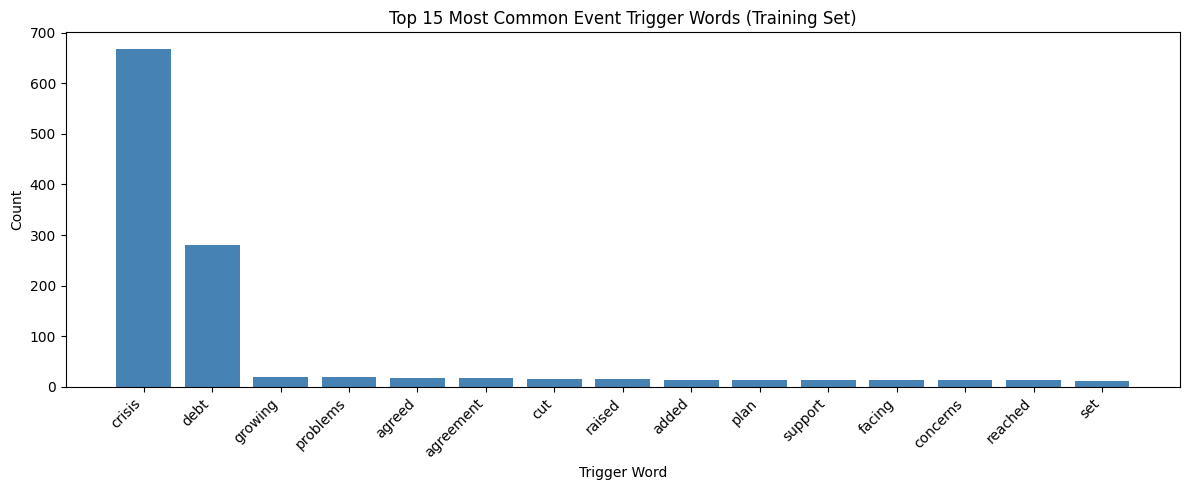

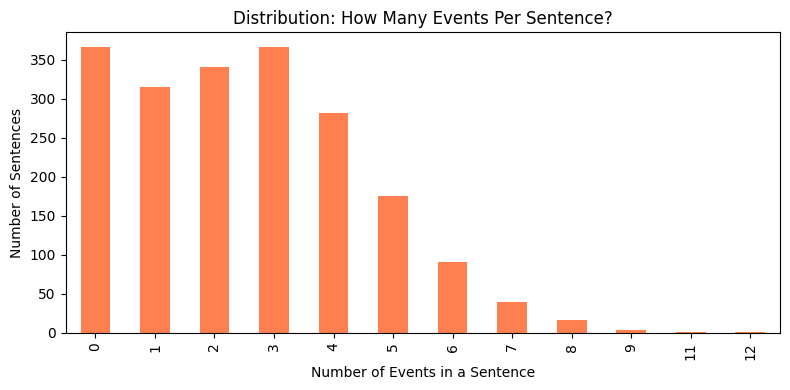

In [ ]:
# Top 15 trigger words
top_events = event_counts.most_common(15)
words, counts = zip(*top_events)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Most Common Event Trigger Words (Training Set)')
plt.xlabel('Trigger Word')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Events per sentence distribution
plt.figure(figsize=(8, 4))
train_df['num_events'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Distribution: How Many Events Per Sentence?')
plt.xlabel('Number of Events in a Sentence')
plt.ylabel('Number of Sentences')
plt.tight_layout()
plt.show()

In [ ]:
print("=== Sentences WITH events ===\n")
for _, row in train_df[train_df['has_event']].head(2).iterrows():
    print(f"Text   : {row['plain_text']}")
    print(f"Events : {row['events']}")
    print()

print("=== Sentences WITHOUT events ===\n")
for _, row in train_df[~train_df['has_event']].head(2).iterrows():
    print(f"Text   : {row['plain_text']}")
    print()

=== Sentences WITH events ===

Text   : one senior official said, referring to the Administration's decision to lend Mexico $12.5 billion to help it through a devastating financial crisis last year.
''
Events : ['said']

Text   : Joseph Burke, the company's chief financial officer, said that the company had little long-term debt and did not ''completely understand'' the rationale of Standard & Poor's decision last week to downgrade the company to junk bond status.
Events : ['said', 'debt', 'understand', 'decision', 'downgrade', 'junk']

=== Sentences WITHOUT events ===

Text   : This power to lead and raise financial resources could help pay for the reconstruction of the Soviet economy (or whatever it becomes), arrangements for peace and economic development of the Middle East, and the rescue of the third world from debt and economic decay.

Text   : In 1997, he supplied liquidity again to offset the escalating Asian financial crisis.



In [ ]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

# reload the csv freshly, now from Google Drive
df = pd.read_csv(os.path.join(EXTRACT_ROOT_DIR, 'event_data.csv'))
df['events'] = df['events'].apply(ast.literal_eval)

train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print("Data loaded ✅")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Data loaded ✅
Train: 2000 | Test: 200


In [ ]:
import re

def tokenize(text):
    # split on whitespace but keep punctuation separate
    tokens = re.findall(r"\w+(?:'\w+)?|[^\w\s]", text)
    return tokens

# test it
sample = "The crisis is growing rapidly, according to officials."
print(tokenize(sample))

['The', 'crisis', 'is', 'growing', 'rapidly', ',', 'according', 'to', 'officials', '.']


In [ ]:
import re

def tokenize(text):
    return re.findall(r"\w+(?:'\w+)?|[^\w\s]", text)


def make_bio_tags(plain_text, events):
    tokens = tokenize(plain_text)
    tokens_lower = [t.lower() for t in tokens]

    # initialize all labels as 'O'
    labels = ['O'] * len(tokens)

    for event in events:
        event_tokens = tokenize(event.lower())

        # sliding window match
        for i in range(len(tokens_lower) - len(event_tokens) + 1):
            if tokens_lower[i:i+len(event_tokens)] == event_tokens:
                labels[i] = 'B'
                for j in range(1, len(event_tokens)):
                    labels[i+j] = 'I'

    return tokens, labels

In [ ]:
# test it
text = "The economic crisis is growing rapidly, according to officials."
events = ["economic crisis", "growing"]

tokens, labels = make_bio_tags(text, events)

print(f"{'Index':<6} {'Token':<15} {'Label'}")
print("-" * 32)

for i, (token, label) in enumerate(zip(tokens, labels)):
    print(f"{i:<6} {token:<15} {label}")

Index  Token           Label
--------------------------------
0      The             O
1      economic        B
2      crisis          I
3      is              O
4      growing         B
5      rapidly         O
6      ,               O
7      according       O
8      to              O
9      officials       O
10     .               O


In [ ]:
def preprocess_row(row):
    tokens, labels = make_bio_tags(row['plain_text'], row['events'])

    # ensure tokens and labels match
    assert len(tokens) == len(labels), "Mismatch between tokens and labels"

    return pd.Series({
        'tokens': tokens,
        'labels': labels,
        'num_tokens': len(tokens)
    })


# apply to train and test
train_processed = train_df.join(train_df.apply(preprocess_row, axis=1))
test_processed  = test_df.join(test_df.apply(preprocess_row, axis=1))

print("Preprocessing done ✅")

print(f"Train shape: {train_processed.shape}")
print(f"Test shape : {test_processed.shape}")

# improved sample print
print("\nSample row:")
tokens = train_processed.iloc[1]['tokens']
labels = train_processed.iloc[1]['labels']

print(f"{'Token':15s} Label")
print("-" * 22)

for t, l in zip(tokens, labels):
    print(f"{t:15s} {l}")

Preprocessing done ✅
Train shape: (2000, 8)
Test shape : (200, 8)

Sample row:
Token           Label
----------------------
Joseph          O
Burke           O
,               O
the             O
company's       O
chief           O
financial       O
officer         O
,               O
said            B
that            O
the             O
company         O
had             O
little          O
long            O
-               O
term            O
debt            B
and             O
did             O
not             O
'               O
'               O
completely      O
understand      B
'               O
'               O
the             O
rationale       O
of              O
Standard        O
&               O
Poor's          O
decision        B
last            O
week            O
to              O
downgrade       B
the             O
company         O
to              O
junk            B
bond            O
status          O
.               O


In [ ]:
from collections import Counter

# flatten all labels
all_labels = [label for labels in train_processed['labels'] for label in labels]

# count frequencies
label_counts = Counter(all_labels)

# safely get counts (in case some labels are missing)
num_O = label_counts.get('O', 0)
num_B = label_counts.get('B', 0)
num_I = label_counts.get('I', 0)

total = num_O + num_B + num_I

print("=== Label Distribution (Train) ===")
print(f"  O (non-event) : {num_O:,}")
print(f"  B (begin)     : {num_B:,}")
print(f"  I (inside)    : {num_I:,}")
print(f"  Total tokens  : {total:,}")

# percentages
if total > 0:
    print(f"  % O           : {num_O/total*100:.1f}%")
    print(f"  % B           : {num_B/total*100:.1f}%")
    print(f"  % I           : {num_I/total*100:.1f}%")
    print(f"  % events      : {(num_B + num_I)/total*100:.1f}%")

# consistency check
print(f"\nConsistency check:")
print(f"  Total event tokens (B + I): {num_B + num_I}")
print(f"  Total B (event starts)   : {num_B}")

=== Label Distribution (Train) ===
  O (non-event) : 70,881
  B (begin)     : 5,165
  I (inside)    : 0
  Total tokens  : 76,046
  % O           : 93.2%
  % B           : 6.8%
  % I           : 0.0%
  % events      : 6.8%

Consistency check:
  Total event tokens (B + I): 5165
  Total B (event starts)   : 5165


In [ ]:
# save tokens and labels as csv to Google Drive
train_processed[['plain_text', 'tokens', 'labels', 'split']].to_csv(os.path.join(EXTRACT_ROOT_DIR, 'train_processed.csv'), index=False)
test_processed[['plain_text', 'tokens', 'labels', 'split']].to_csv(os.path.join(EXTRACT_ROOT_DIR, 'test_processed.csv'), index=False)

print(f"Saved {os.path.join(EXTRACT_ROOT_DIR, 'train_processed.csv')} ✅")
print(f"Saved {os.path.join(EXTRACT_ROOT_DIR, 'test_processed.csv')}  ✅")

Saved /content/drive/My Drive/event_dataset/train_processed.csv ✅
Saved /content/drive/My Drive/event_dataset/test_processed.csv  ✅


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
print("NLTK ready ✅")

NLTK ready ✅


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import nltk
from nltk import pos_tag

def extract_features(tokens, i):
    token = tokens[i]
    pos_tags = pos_tag(tokens)  # get POS tags for whole sentence

    features = {
        # the word itself
        'word': token.lower(),

        # word shape features
        'is_capitalized': token[0].isupper(),
        'is_all_caps': token.isupper(),
        'is_numeric': token.isdigit(),
        'has_hyphen': '-' in token,
        'word_length': len(token),

        # POS tag (is it a verb, noun, etc.)
        'pos_tag': pos_tags[i][1],
        'is_verb': pos_tags[i][1].startswith('VB'),
        'is_noun': pos_tags[i][1].startswith('NN'),

        # prefix and suffix (helps catch word endings like -ing, -ed)
        'prefix_2': token[:2].lower(),
        'prefix_3': token[:3].lower(),
        'suffix_2': token[-2:].lower(),
        'suffix_3': token[-3:].lower(),

        # previous word context
        'prev_word': tokens[i-1].lower() if i > 0 else '<START>',
        'prev_pos':  pos_tags[i-1][1]    if i > 0 else '<START>',

        # next word context
        'next_word': tokens[i+1].lower() if i < len(tokens)-1 else '<END>',
        'next_pos':  pos_tags[i+1][1]    if i < len(tokens)-1 else '<END>',
    }
    return features

# test it on one token
sample_tokens = ['The', 'crisis', 'is', 'growing', 'rapidly']
print("Features for 'crisis':")
for k, v in extract_features(sample_tokens, 1).items():
    print(f"  {k:20s} → {v}")

Features for 'crisis':
  word                 → crisis
  is_capitalized       → False
  is_all_caps          → False
  is_numeric           → False
  has_hyphen           → False
  word_length          → 6
  pos_tag              → NN
  is_verb              → False
  is_noun              → True
  prefix_2             → cr
  prefix_3             → cri
  suffix_2             → is
  suffix_3             → sis
  prev_word            → the
  prev_pos             → DT
  next_word            → is
  next_pos             → VBZ


In [ ]:
import ast
import pandas as pd

# reload processed data from Google Drive
train_processed = pd.read_csv(os.path.join(EXTRACT_ROOT_DIR, 'train_processed.csv'))
test_processed  = pd.read_csv(os.path.join(EXTRACT_ROOT_DIR, 'test_processed.csv'))

train_processed['tokens'] = train_processed['tokens'].apply(ast.literal_eval)
train_processed['labels'] = train_processed['labels'].apply(ast.literal_eval)
test_processed['tokens']  = test_processed['tokens'].apply(ast.literal_eval)
test_processed['labels']  = test_processed['labels'].apply(ast.literal_eval)

print("Building features for training set (this may take 1-2 mins)...")
X_train, y_train = [], []
for _, row in train_processed.iterrows():
    tokens = row['tokens']
    labels = row['labels']
    for i in range(len(tokens)):
        X_train.append(extract_features(tokens, i))
        y_train.append(labels[i])

print("Building features for test set...")
X_test, y_test = [], []
for _, row in test_processed.iterrows():
    tokens = row['tokens']
    labels = row['labels']
    for i in range(len(tokens)):
        X_test.append(extract_features(tokens, i))
        y_test.append(labels[i])

print(f"\nTraining samples (tokens) : {len(X_train):,}")
print(f"Test samples (tokens)     : {len(X_test):,}")
print("Feature extraction done ✅")

Building features for training set (this may take 1-2 mins)...
Building features for test set...

Training samples (tokens) : 76,046
Test samples (tokens)     : 7,335
Feature extraction done ✅


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.pipeline import Pipeline
import numpy as np

# DictVectorizer converts our feature dicts into a numeric matrix
pipeline = Pipeline([
    ('vectorizer', DictVectorizer(sparse=True)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # handles our 93/7 imbalance
        random_state=42
    ))
])

print("Training Logistic Regression...")
pipeline.fit(X_train, y_train)
print("Training done ✅")

Training Logistic Regression...
Training done ✅


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("=== Baseline Model Results ===\n")

# force the order → 0=O (non-event), 1=B (event)
print(classification_report(
    y_test,
    y_pred,
    labels=['O', 'B'],          # O first, B second → correct order
    target_names=['O (non-event)', 'B (event)']
))

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['O', 'B'])  # O first, B second
print("Confusion Matrix:")
print(f"                    Predicted O    Predicted B")
print(f"Actual O (non-event):   {cm[0][0]:5d}          {cm[0][1]:5d}")
print(f"Actual B (event)    :   {cm[1][0]:5d}          {cm[1][1]:5d}")

=== Baseline Model Results ===

               precision    recall  f1-score   support

O (non-event)       0.99      0.90      0.94      6916
    B (event)       0.35      0.87      0.50       419

     accuracy                           0.90      7335
    macro avg       0.67      0.89      0.72      7335
 weighted avg       0.96      0.90      0.92      7335

Confusion Matrix:
                    Predicted O    Predicted B
Actual O (non-event):    6242            674
Actual B (event)    :      53            366


In [ ]:
def predict_sentence(text):
    from nltk import word_tokenize
    import re
    tokens = re.findall(r"\w+(?:'\w+)?|[^\w\s]", text)
    features = [extract_features(tokens, i) for i in range(len(tokens))]
    predictions = pipeline.predict(features)

    print(f"\nText: {text}\n")
    print(f"{'Token':20s} Prediction")
    print("-" * 35)
    for token, pred in zip(tokens, predictions):
        marker = " ← EVENT" if pred == 'B' else ""
        print(f"{token:20s} {pred}{marker}")

# try some examples
predict_sentence("The government collapsed after the minister resigned from office.")
predict_sentence("The meeting was scheduled for next Thursday afternoon.")
predict_sentence("Thousands of protesters gathered in the capital city.")


Text: The government collapsed after the minister resigned from office.

Token                Prediction
-----------------------------------
The                  O
government           O
collapsed            O
after                O
the                  O
minister             O
resigned             B ← EVENT
from                 O
office               O
.                    O

Text: The meeting was scheduled for next Thursday afternoon.

Token                Prediction
-----------------------------------
The                  O
meeting              B ← EVENT
was                  O
scheduled            B ← EVENT
for                  O
next                 O
Thursday             O
afternoon            O
.                    O

Text: Thousands of protesters gathered in the capital city.

Token                Prediction
-----------------------------------
Thousands            O
of                   O
protesters           O
gathered             B ← EVENT
in                   O
the          

In [ ]:
import torch
print(torch.cuda.is_available())   # should print True
print(torch.cuda.get_device_name(0))  # should print Tesla T4


True
Tesla T4


In [ ]:
!pip install transformers datasets seqeval -q
print("Installed ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installed ✅


In [ ]:
import torch
import numpy as np
import pandas as pd
import ast
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW                         # ← from torch, not transformers
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    get_linear_schedule_with_warmup
)
from seqeval.metrics import classification_report as seq_classification_report
print("Imports done ✅")

Imports done ✅


In [ ]:
train_processed = pd.read_csv(os.path.join(EXTRACT_ROOT_DIR, 'train_processed.csv'))
test_processed  = pd.read_csv(os.path.join(EXTRACT_ROOT_DIR, 'test_processed.csv'))

train_processed['tokens'] = train_processed['tokens'].apply(ast.literal_eval)
train_processed['labels'] = train_processed['labels'].apply(ast.literal_eval)
test_processed['tokens']  = test_processed['tokens'].apply(ast.literal_eval)
test_processed['labels']  = test_processed['labels'].apply(ast.literal_eval)

print(f"Train: {len(train_processed)} | Test: {len(test_processed)} ✅")

Train: 2000 | Test: 200 ✅


In [ ]:
# convert B/O labels to numbers (BERT needs numbers not strings)
label2id = {'O': 0, 'B': 1}
id2label = {0: 'O', 1: 'B'}

print("Label mapping:")
print(f"  O (non-event) → 0")
print(f"  B (event)     → 1")

Label mapping:
  O (non-event) → 0
  B (event)     → 1


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
print("Tokenizer loaded ✅")

# understand what BERT tokenizer does
sample = ['The', 'crisis', 'is', 'growing', 'rapidly']
encoded = tokenizer(sample, is_split_into_words=True, return_tensors='pt')
print(f"\nSample tokens  : {sample}")
print(f"BERT input ids : {encoded['input_ids']}")
print(f"Word ids       : {encoded.word_ids()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded ✅

Sample tokens  : ['The', 'crisis', 'is', 'growing', 'rapidly']
BERT input ids : tensor([[ 101, 1996, 5325, 2003, 3652, 5901,  102]])
Word ids       : [None, 0, 1, 2, 3, 4, None]


In [ ]:
# BERT splits some words into subwords
sample2 = ['administration', 'collapsing', 'unfortunately']
encoded2 = tokenizer(sample2, is_split_into_words=True)

print("How BERT splits words into subwords:\n")
tokens = tokenizer.convert_ids_to_tokens(encoded2['input_ids'])
word_ids = encoded2.word_ids()

print(f"{'BERT token':20s} {'Word ID':10s}")
print("-" * 35)
for token, wid in zip(tokens, word_ids):
    print(f"{token:20s} {str(wid):10s}")


How BERT splits words into subwords:

BERT token           Word ID   
-----------------------------------
[CLS]                None      
administration       0         
collapsing           1         
unfortunately        2         
[SEP]                None      


In [ ]:
class EventDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label2id, max_len=128):
        self.data      = dataframe
        self.tokenizer = tokenizer
        self.label2id  = label2id
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data.iloc[idx]['tokens']
        labels = self.data.iloc[idx]['labels']

        # tokenize — BERT may split words into subwords
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # align labels with subword tokens
        word_ids    = encoding.word_ids()
        aligned_labels = []
        prev_word_id   = None

        for word_id in word_ids:
            if word_id is None:
                # special tokens [CLS] and [SEP] → ignore (-100)
                aligned_labels.append(-100)
            elif word_id != prev_word_id:
                # first subword of a word → give it the real label
                aligned_labels.append(self.label2id[labels[word_id]])
            else:
                # continuation subword → ignore (-100)
                aligned_labels.append(-100)
            prev_word_id = word_id

        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'token_type_ids': encoding['token_type_ids'].squeeze(),
            'labels':         torch.tensor(aligned_labels, dtype=torch.long)
        }

# create datasets
train_dataset = EventDataset(train_processed, tokenizer, label2id)
test_dataset  = EventDataset(test_processed,  tokenizer, label2id)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Dataset ready ✅")

Train batches : 125
Test batches  : 13
Dataset ready ✅


In [ ]:
model = BertForTokenClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,           # O and B
    id2label=id2label,
    label2id=label2id
)

model = model.to('cuda')   # move to GPU

# count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable:,}")
print("Model loaded on GPU ✅")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Total parameters     : 108,893,186
Trainable parameters : 108,893,186
Model loaded on GPU ✅


In [ ]:
EPOCHS    = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps    = len(train_loader) * EPOCHS
warmup_steps   = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Epochs               : {EPOCHS}")
print("Optimizer ready ✅")

Total training steps : 375
Warmup steps         : 37
Epochs               : 3
Optimizer ready ✅


In [ ]:
from tqdm import tqdm
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix

# reload fresh model
model = BertForTokenClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    id2label=id2label,
    label2id=label2id
).to('cuda')

EPOCHS = 3   # was 3 before

optimizer    = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs       : {EPOCHS}")
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"Starting training...\n")

# train
best_f1   = 0
best_epoch = 0

model.train()
for epoch in range(EPOCHS):
    total_loss  = 0
    num_batches = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in loop:
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to('cuda')
        attention_mask = batch['attention_mask'].to('cuda')
        token_type_ids = batch['token_type_ids'].to('cuda')
        labels         = batch['labels'].to('cuda')

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss  += loss.item()
        num_batches += 1
        loop.set_postfix(loss=total_loss/num_batches)

    avg_loss = total_loss / num_batches

    # evaluate after every epoch
    model.eval()
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda')
            token_type_ids = batch['token_type_ids'].to('cuda')
            labels         = batch['labels'].to('cuda')

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            preds = torch.argmax(outputs.logits, dim=-1)

            for pred_seq, label_seq in zip(preds, labels):
                pred_list, label_list = [], []
                for p, l in zip(pred_seq, label_seq):
                    if l.item() != -100:
                        pred_list.append(id2label[p.item()])
                        label_list.append(id2label[l.item()])
                all_preds.append(pred_list)
                all_labels_list.append(label_list)

    flat_preds  = [p for seq in all_preds       for p in seq]
    flat_labels = [l for seq in all_labels_list for l in seq]

    report = classification_report(
        flat_labels, flat_preds,
        labels=['O', 'B'],
        target_names=['O (non-event)', 'B (event)'],
        output_dict=True
    )

    b_f1 = report['B (event)']['f1-score']
    b_p  = report['B (event)']['precision']
    b_r  = report['B (event)']['recall']

    # track best epoch
    if b_f1 > best_f1:
        best_f1    = b_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), '/content/best_model.pt')  # save best

    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | P: {b_p:.2f} | R: {b_r:.2f} | F1: {b_f1:.2f} {'← best' if best_epoch == epoch+1 else ''}")

    model.train()

print(f"\n✅ Best F1 = {best_f1:.2f} at Epoch {best_epoch}")
print(f"Best model saved to /content/best_model.pt")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Epochs       : 3
Total steps  : 375
Warmup steps : 37
Starting training...



Epoch 1/3: 100%|██████████| 125/125 [00:53<00:00,  2.32it/s, loss=0.185]


Epoch  1 | Loss: 0.1846 | P: 0.66 | R: 0.67 | F1: 0.66 ← best


Epoch 2/3: 100%|██████████| 125/125 [00:50<00:00,  2.47it/s, loss=0.0802]


Epoch  2 | Loss: 0.0802 | P: 0.59 | R: 0.82 | F1: 0.68 ← best


Epoch 3/3: 100%|██████████| 125/125 [00:50<00:00,  2.47it/s, loss=0.0646]


Epoch  3 | Loss: 0.0646 | P: 0.61 | R: 0.79 | F1: 0.69 ← best

✅ Best F1 = 0.69 at Epoch 3
Best model saved to /content/best_model.pt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
